In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

**DATA LOADING**

In [3]:
file_path = "/content/drive/Shareddrives/CS 273: Project 1 - Group # 5/group5_raw_data/IADSED-2.csv"
iadsed_df = pd.read_csv(file_path)
print("Dataset shape:", iadsed_df.shape)
display(iadsed_df.head())

Dataset shape: (935, 76)


,source,description,category,fname,BE_Classification,arousal,valence,dominance,dynamics_rms_mean,dynamics_rms_std,...,timbre_lowenergy_std,timbre_spectralflux_mean,timbre_spectralflux_std,pitch_pitch_mean,tonal_keyclarity_mean,tonal_keyclarity_std,tonal_mode_mean,tonal_mode_std,tonal_hcdf_mean,tonal_hcdf_std
0,Expanded,LightMusic24,Music,1,H,4.181818,6.545455,5.73,0.095067,0.042815,...,1.422069,48.254947,24.727503,528.017203,0.432155,0.109549,-0.023553,0.080957,0.150785,0.130867
1,Expanded,Sci-Fi4,Sound Effect,2,F,6.181818,3.227273,3.55,0.077893,0.039497,...,2.560911,71.886219,35.961220,625.613178,0.529449,0.150595,-0.019567,0.117713,0.268396,0.130745
2,Expanded,Suspense Thriller1,Sound Effect,3,FS,5.227273,4.227273,4.23,0.069022,0.038171,...,2.168929,49.664474,28.268124,550.618550,0.454158,0.162282,-0.025239,0.038950,0.108528,0.105093
3,Expanded,Suspense Thriller2,Sound Effect,0003_b,FS,5.500000,4.500000,4.86,0.081225,0.048385,...,2.323706,59.662149,35.983242,555.333945,0.622735,0.088611,-0.055778,0.078180,0.169863,0.099310
4,Expanded,HorrorFilm7,Sound Effect,4,F,6.541667,4.208333,3.88,0.092900,0.023437,...,1.294244,67.776311,17.871596,489.432139,0.458862,0.119900,0.017167,0.104018,0.169086,0.090438


In [5]:
iadsed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 935 entries, 0 to 934
Data columns (total 76 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   source                             935 non-null    object 
 1   description                        935 non-null    object 
 2   category                           935 non-null    object 
 3   fname                              935 non-null    object 
 4   BE_Classification                  935 non-null    object 
 5   arousal                            935 non-null    float64
 6   valence                            935 non-null    float64
 7   dominance                          935 non-null    float64
 8   dynamics_rms_mean                  935 non-null    float64
 9   dynamics_rms_std                   935 non-null    float64
 10  rhythm_attacktime_mean             935 non-null    float64
 11  rhythm_tempo_mean                  934 non-null    float64

In [4]:
missing_values = iadsed_df.isnull().sum()
display(missing_values[missing_values > 0].to_frame("missing_count"))
print("Rows with missing values:", iadsed_df.isnull().any(axis=1).sum())
print("Duplicate rows:", iadsed_df.duplicated().sum())

,missing_count
rhythm_tempo_mean,1
rhythm_tempo_std,2
tonal_keyclarity_mean,6
tonal_keyclarity_std,6
tonal_mode_std,6
tonal_hcdf_std,6


Rows with missing values: 8
Duplicate rows: 0


**DATA CLEANING**

In [6]:
iadsed_clean_df = iadsed_df.copy()
iadsed_clean_df.drop(columns=["dominance"], inplace=True)
iadsed_clean_df.dropna(inplace=True)
iadsed_clean_df.reset_index(drop=True, inplace=True)

print("Original shape:", iadsed_df.shape)
print("Cleaned shape:", iadsed_clean_df.shape)
print("Remaining missing values:", iadsed_clean_df.isnull().sum().sum())

Original shape: (935, 76)
Cleaned shape: (927, 75)
Remaining missing values: 0


**DATA VISUALIZATION**

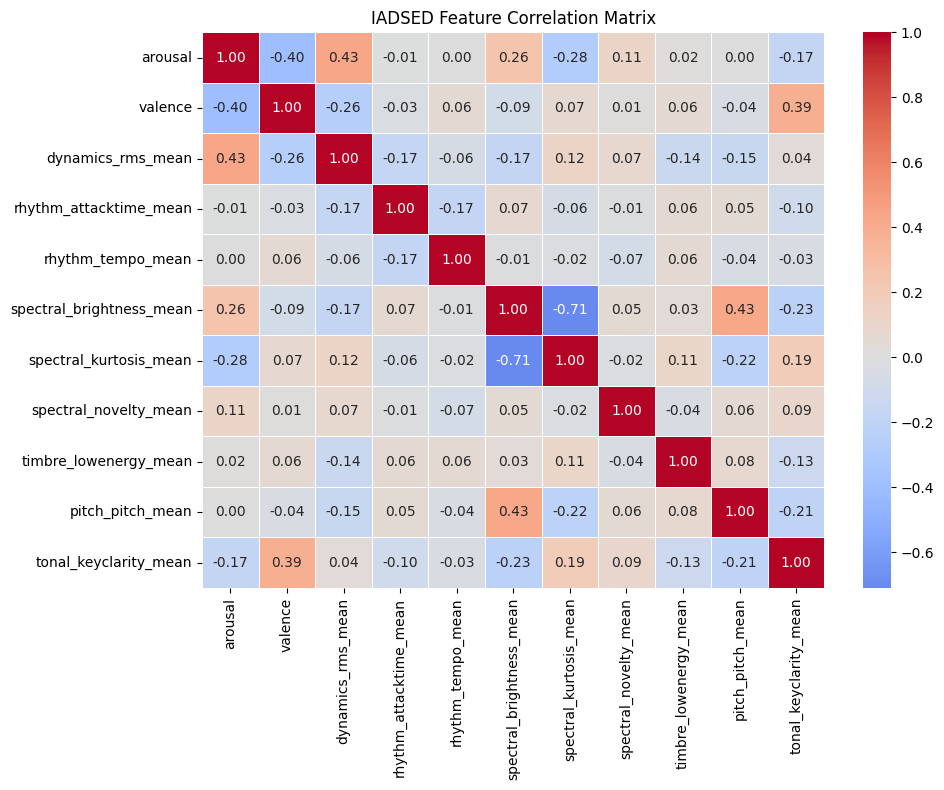

In [7]:
correlation_columns = ["arousal", "valence", "dynamics_rms_mean", "rhythm_attacktime_mean", "rhythm_tempo_mean", "spectral_brightness_mean", "spectral_kurtosis_mean", "spectral_novelty_mean", "timbre_lowenergy_mean", "pitch_pitch_mean", "tonal_keyclarity_mean"]
correlation_matrix = iadsed_clean_df[correlation_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f", linewidths=0.5)
plt.title("IADSED Feature Correlation Matrix")
plt.tight_layout()
plt.show()

**DATA PREPROCESSING**

In [8]:
metadata_columns = ["source", "description", "category", "fname", "BE_Classification"]
iadsed_preprocessed_df = iadsed_clean_df.drop(columns=metadata_columns)
preprocessed_path = "/content/drive/Shareddrives/CS 273: Project 1 - Group # 5/group5_preprocessed_data/IADSED_preprocessed.csv"
iadsed_preprocessed_df.to_csv(preprocessed_path, index=False)

print("Saved dataset shape:", iadsed_preprocessed_df.shape)
print("Missing values:", iadsed_preprocessed_df.isnull().sum().sum())

Saved dataset shape: (927, 70)
Missing values: 0


**DATA SPLITTING**

In [9]:
modeling_df = pd.read_csv(preprocessed_path)
target_columns = ["arousal", "valence"]

train_validation_df, test_df = train_test_split(modeling_df, test_size=0.20, random_state=42, shuffle=True)
train_df, validation_df = train_test_split(train_validation_df, test_size=0.25, random_state=42, shuffle=True)

print("Training shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)

Training shape: (555, 70)
Validation shape: (186, 70)
Test shape: (186, 70)


In [10]:
train_validation_df = pd.concat([train_df, validation_df], ignore_index=True)
X_train_validation = train_validation_df.drop(columns=target_columns)
y_train_validation = train_validation_df[target_columns]
X_test = test_df.drop(columns=target_columns)
y_test = test_df[target_columns]

print("Training + validation features:", X_train_validation.shape)
print("Test features:", X_test.shape)
print("Training + validation targets:", y_train_validation.shape)
print("Test targets:", y_test.shape)

Training + validation features: (741, 68)
Test features: (186, 68)
Training + validation targets: (741, 2)
Test targets: (186, 2)


**MODEL TRAINING**

In [11]:
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

model_configurations = {
    "Linear Regression": {
        "model": LinearRegression(),
        "parameters": {"model__fit_intercept": [True, False]},
        "search_method": "grid"
    },
    "Random Forest": {
        "model": RandomForestRegressor(random_state=42, n_jobs=1),
        "parameters": {
            "model__n_estimators": [100, 150],
            "model__max_depth": [12, None],
            "model__min_samples_leaf": [1, 3],
            "model__max_features": ["sqrt", 0.5]
        },
        "search_method": "random"
    },
    "Gradient Boosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "parameters": {
            "model__n_estimators": [100, 150],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [2, 3],
            "model__min_samples_leaf": [1, 3]
        },
        "search_method": "random"
    }
}

In [12]:
def calculate_rmse(actual, predicted):
    return np.sqrt(mean_squared_error(actual, predicted))

def train_model(target, model_name, configuration, use_feature_selection):
    steps = []

    if use_feature_selection:
        steps.append(("selector", SelectKBest(score_func=f_regression)))

    if model_name == "Linear Regression":
        steps.append(("scaler", MinMaxScaler()))

    steps.append(("model", clone(configuration["model"])))
    pipeline = Pipeline(steps)
    parameters = configuration["parameters"].copy()

    if use_feature_selection:
        parameters["selector__k"] = [20, 40]

    if configuration["search_method"] == "grid":
        search = GridSearchCV(pipeline, parameters, scoring="neg_root_mean_squared_error", cv=cv_strategy, n_jobs=-1, refit=True, verbose=1)
    else:
        search = RandomizedSearchCV(pipeline, parameters, n_iter=4, scoring="neg_root_mean_squared_error", cv=cv_strategy, n_jobs=-1, refit=True, random_state=42, verbose=1)

    search.fit(X_train_validation, y_train_validation[target])
    train_predictions = search.predict(X_train_validation)
    test_predictions = search.predict(X_test)

    return {
        "target": target,
        "model": model_name,
        "feature_selection": "With FS" if use_feature_selection else "Without FS",
        "selected_feature_count": search.best_params_.get("selector__k", X_train_validation.shape[1]),
        "cv_rmse": -search.best_score_,
        "train_rmse": calculate_rmse(y_train_validation[target], train_predictions),
        "test_rmse": calculate_rmse(y_test[target], test_predictions),
        "best_parameters": search.best_params_
    }

**Train models without feature selection**

In [17]:
results_without_fs = []

for target in target_columns:
    for model_name, configuration in model_configurations.items():
        print(f"Training {target} - {model_name}", flush=True)
        result = train_model(target, model_name, configuration, False)
        results_without_fs.append(result)
        print(f"Completed: CV RMSE = {result['cv_rmse']:.4f}", flush=True)

results_without_fs_df = pd.DataFrame(results_without_fs)

Training arousal - Linear Regression
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Completed: CV RMSE = 0.8717
Training arousal - Random Forest
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Completed: CV RMSE = 0.7847
Training arousal - Gradient Boosting
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Completed: CV RMSE = 0.7721
Training valence - Linear Regression
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Completed: CV RMSE = 1.1985
Training valence - Random Forest
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Completed: CV RMSE = 1.1101
Training valence - Gradient Boosting
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Completed: CV RMSE = 1.1366


**Train models with feature selection**

In [20]:
results_with_fs = []

for target in target_columns:
    for model_name, configuration in model_configurations.items():
        print("Training with FS:", target, "-", model_name)
        result = train_model(target, model_name, configuration, True)
        results_with_fs.append(result)

results_with_fs_df = pd.DataFrame(results_with_fs)

Training with FS: arousal - Linear Regression
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Training with FS: arousal - Random Forest
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Training with FS: arousal - Gradient Boosting
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Training with FS: valence - Linear Regression
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Training with FS: valence - Random Forest
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Training with FS: valence - Gradient Boosting
Fitting 5 folds for each of 4 candidates, totalling 20 fits


In [21]:
before_fs = results_without_fs_df[["target", "model", "cv_rmse", "train_rmse", "test_rmse"]]
after_fs = results_with_fs_df[["target", "model", "selected_feature_count", "cv_rmse", "train_rmse", "test_rmse"]]
comparison_df = before_fs.merge(after_fs, on=["target", "model"], suffixes=("_before_fs", "_after_fs"))
comparison_df["test_rmse_change"] = comparison_df["test_rmse_after_fs"] - comparison_df["test_rmse_before_fs"]
comparison_df["fs_result"] = np.where(comparison_df["test_rmse_change"] < 0, "Improved", "Did not improve")
display(comparison_df.round(4))

,target,model,cv_rmse_before_fs,train_rmse_before_fs,test_rmse_before_fs,selected_feature_count,cv_rmse_after_fs,train_rmse_after_fs,test_rmse_after_fs,test_rmse_change,fs_result
0,arousal,Linear Regression,0.8717,0.7681,0.8422,40,0.8663,0.8102,0.8114,-0.0308,Improved
1,arousal,Random Forest,0.7847,0.3082,0.6942,40,0.7843,0.2933,0.7184,0.0242,Did not improve
2,arousal,Gradient Boosting,0.7721,0.4611,0.7145,40,0.7728,0.5024,0.7258,0.0112,Did not improve
3,valence,Linear Regression,1.1985,1.0705,1.2404,20,1.1987,1.1546,1.2396,-0.0009,Improved
4,valence,Random Forest,1.1101,0.4484,1.1093,40,1.1069,0.5480,1.1080,-0.0013,Improved
5,valence,Gradient Boosting,1.1366,0.6925,1.0884,40,1.1253,0.7227,1.1363,0.0479,Did not improve
